# **--- UBER PROJECT ---** #

## **I. EDA** ##

### **1. Libraries import** ###

In [521]:
import pandas as pd
import numpy as np
import os
import json


from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

The information about the Uber rides are spread into several datasets :
- One CSV file per month from April to September 2014,
- One CSV file with all the months from January to June 2015,
- Then, one CSV file with the taxi zones.

First, we create a global dataset that is a concatenation of random and stratified samples of each dataset containing the rides information.
=> This allow us to check variations throught different times (day, week, season, etc), without loading everything in memory.

Then, we make a montly and deeper analysis to check specific information.

### **2. Preparation of datasets for EDA** ###

**2.1. Analyse the schema of each CSV file**

Before taking samples of each dataset in order to combine them into a global dataset, we need to check their structure to see how we can concatenate them.

In [ ]:
# For memory issue, we load only the headers of each CSV file:

folder=r"../DATA/DATA_raw"
files=sorted(os.listdir(folder))

for file in files:
    file_path = os.path.join(folder, file)

    if not os.path.isfile(file_path):
        continue
    if not file.endswith(".csv"):
        continue
    try:
        # We only read the headers
        df = pd.read_csv(file_path, nrows=0, encoding="utf-8")
    
    except UnicodeDecodeError:
        df = pd.read_csv(file_path, nrows=0, encoding="latin-1")

    except Exception as e:
        print(f"Erreur avec {file}: {e}")
        continue

    print(f"File: {file} / Columns: {list(df.columns)}")

- All the files from 2014 have the same structure and can be easily concatenated.
- The dataset containing information from 2015 has a different structure than the datasets from 2015, with a `Dispatching_base_num` and an `Affiliated_base_num` whereas we only have the `Base` column for the 2014 datasets.
=> The 2014 datasets have raw geolocation (`Lat`and `Lon`) / The 2015 dataset has a `locationID` (that refers to the taxi zones).The 2014 and 2015 datasets describe Uber pickups but in differant formats (GPS coordinates vs aggregated taxi zones).

So we can perform detailed EDA on the following datasets:
- one unified 2014 dataset (sampling + merge of the differents 2014 datasets)
- one 2015 dataset (sampling only)

Then, if relevant, we can unify them after unifying the geolocations.

**2.2. Preparing the 2014 dataset**

We build a representative stratified sample of the 2014 datasets (from April to September) in order to run an EDA and clustering models efficiently without overloading our machine. The stratification by month, weekday and hour is essential in order to be representative of the reality.

In [ ]:
sampled_parts = []
files_2014=sorted([f for f in os.listdir(folder) if f.endswith("14.csv")])

for file in files_2014:
    file_path = os.path.join(folder, file)
    df = pd.read_csv(file_path, parse_dates=['Date/Time']) # with parse_dates we automatically convert the column into a datetime format (instead of a string).
    df['Month'] = df['Date/Time'].dt.month_name()
    df['Weekday'] = df['Date/Time'].dt.day_name()
    df['Hour'] = df['Date/Time'].dt.hour

    # We create a column combining month / weekday / hour in order to use these criteria for our stratification
    df['Strata'] = df['Month'] + '_' + df['Weekday'] + '_' + df['Hour'].astype(str)

    # Within each subgroup created by a "groupby" operation on the "Strata" column we randomly pick 5% of the rows.
    # in order to keep the same proportion of rides from each time slot.
    part = df.drop(columns=['Strata']).groupby(df['Strata'], group_keys=False).apply(lambda x: x.sample(frac=0.05, random_state=42))
    # We use group_keys=False so Pandas doesn’t add the group labels (so we don't end up with a multi-index DataFrame)
    # We use df['Strata'] as a key for the groupby but we delete it from the Dataframe to avoid a DeprecationWarning

    sampled_parts.append(part)

uber_2014_sampled = pd.concat(sampled_parts, ignore_index=True)
uber_2014_sampled.tail()


In [ ]:
uber_2014_sampled.to_csv("../DATA/DATA_created/uber_2014_sampled.csv", index=False)

**2.3. Extract Latitude and Longitude from taxi zones**

The 2015 dataset does not contain latitude and longitude information like the dataset of 2014. Instead it contains the `LocationID` variable wich corresponds to the same variable in the `taxi-zone-lookup.csv` file. By merging these dataset we can collect the `Zone`and `Borough`, which are previously used to call the Nominatum API to get the latitude and longitude.  Our final 2015 dataset will then get the coordinates informations.

*2.3.1. Get taxi zones coordinates from the API*

We will use the library Geopy from Python to make the Nominatum API calls.

In [ ]:
!pip install geopy

In [ ]:
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut
import time
import plotly.express as px

To extract the coordinates, we will have to make sure that the points we are looking for are within our borough and not somewhere else in the USA or in the world (same name somewhere else).

In [ ]:
# Expanded NYC bounds to include only NYC and nearby areas
NYC_BOUNDS = {
    'lat_min': 40.5,      # South
    'lat_max': 40.95,     # North
    'lon_min': -74.35,    # West
    'lon_max': -73.7      # East
}

In [ ]:
def geocode_taxi_zones(taxi_zone_df):
    """
    Geolocates all NYC taxi zones
    
    Args:
        taxi_zone_df: DataFrame with 'Zone' and 'Borough' columns
        
    Returns:
        DataFrame with coordinates, ready for mapping
    """
    
    geolocator = Nominatim(user_agent="uber_nyc_clustering_final", timeout=15)
    
    results = []
    failed = []
    
    unique_zones = taxi_zone_df[['Zone', 'Borough']].drop_duplicates()
    
    for idx, row in enumerate(unique_zones.itertuples()):
        zone_name = row.Zone
        borough_name = row.Borough
        
        # Clean the name: we remove "/" and "(" and ")"
        # Example: "Allerton/Pelham Gardens" becomes "Allerton Pelham Gardens"
        # and "Park Slope (Brooklyn)" becomes "Park Slope"
        clean_name = zone_name.replace("/", " ").replace("(", "").replace(")", "")
        
        try:
            time.sleep(0.8)
            
            # Query with NYC context
            query = f"{clean_name}, {borough_name}, NYC, USA"
            
            if idx % 50 == 0:
                print(f"Progress: {idx}/{len(unique_zones)}")
            
            location = geolocator.geocode(query)
            
            if location is None:
                failed.append(zone_name)
                continue
            
            lat = float(location.latitude)
            lon = float(location.longitude)
            
            # Check if within expanded NYC bounds
            if not (NYC_BOUNDS['lat_min'] <= lat <= NYC_BOUNDS['lat_max'] and
                    NYC_BOUNDS['lon_min'] <= lon <= NYC_BOUNDS['lon_max']):
                failed.append(zone_name)
                continue
            
            results.append({
                'Zone': zone_name,
                'Borough': borough_name,
                'Latitude': lat,
                'Longitude': lon
            })
        
        except (GeocoderTimedOut, Exception):
            failed.append(zone_name)
            continue
    
    # Create final DataFrame
    final_df = pd.DataFrame(results)
    
    # Merge with original dataset to keep all information
    final_df = pd.merge(
        taxi_zone_df,
        final_df[['Zone','Latitude', 'Longitude']],
        how='left',
        on='Zone'
    )
    
    # Remove rows without coordinates
    final_df = final_df.dropna(subset=['Latitude', 'Longitude'])
    
    
    print(f"\n-Zones found: {len(final_df)}")
    print(f"-Failed zones: {len(failed)}")
    print(f"\nBoroughs represented: {final_df['Borough'].nunique()}")
    for borough in sorted(final_df['Borough'].unique()):
        count = len(final_df[final_df['Borough'] == borough])
        print(f"   - {borough}: {count} zones")
    
    return final_df

In [ ]:
# Load zones
taxi_zone_df = pd.read_csv("../DATA/DATA_raw/8.taxi-zone-lookup.csv")

# Geolocate
final_df = geocode_taxi_zones(taxi_zone_df)

In [ ]:
# Save
final_df.to_csv("../DATA/DATA_created/taxi_zones_coordinates.csv", index=False)

*2.3.2. Merge 2015 Uber data with taxi zone coordinates*

In [ ]:
uber_2015_raw_df = pd.read_csv("../DATA/DATA_raw/7.uber-raw-data-janjune-15.csv")
taxi_zones_coord_df = pd.read_csv("../DATA/DATA_created/taxi_zones_coordinates.csv")

In [ ]:
# Check for missing coordinates in taxi_zones_coord_df
missing_coords = taxi_zones_coord_df[
    taxi_zones_coord_df['Latitude'].isna() | taxi_zones_coord_df['Longitude'].isna()
]

print(f"\nTaxi zones missing coordinates: {len(missing_coords)}")
if len(missing_coords) > 0:
    print("Examples of zones without coordinates:")
    for idx, row in missing_coords.head(10).iterrows():
        print(f"  - {row['Zone']}")

In [ ]:
# Keep only zones WITH coordinates
taxi_zones_with_coords = taxi_zones_coord_df[
    taxi_zones_coord_df['Latitude'].notna() & 
    taxi_zones_coord_df['Longitude'].notna()
].copy()

print(f"\nTaxi zones WITH valid coordinates: {len(taxi_zones_with_coords)}")

In [526]:
taxi_zones_coord_df.columns

Index(['LocationID', 'Borough', 'Zone', 'Latitude', 'Longitude'], dtype='object')

In [525]:
uber_2015_raw_df.columns

Index(['Dispatching_base_num', 'Pickup_date', 'Affiliated_base_num',
       'LocationID'],
      dtype='object')

In [527]:
uber_2015_raw_df =  uber_2015_raw_df.rename(columns={'locationID': 'LocationID'})
# Merge datasets on LocationID
uber_2015_with_coords = uber_2015_raw_df.merge(
    taxi_zones_with_coords[['LocationID', 'Zone','Borough','Latitude', 'Longitude']],
    on='LocationID',
    how='left'
)

print(f"\nAfter merge:")
print(f"  Total rides: {len(uber_2015_with_coords):,}")
print(f"  Rides with coordinates: {uber_2015_with_coords['Latitude'].notna().sum():,}")
print(f"  Rides without coordinates: {uber_2015_with_coords['Latitude'].isna().sum():,}")



After merge:
  Total rides: 14,270,479
  Rides with coordinates: 10,017,078
  Rides without coordinates: 4,253,401


In [528]:
# Clean: separate rides without coordinates in another table
uber_2015_clean = uber_2015_with_coords[
    uber_2015_with_coords['Latitude'].notna() & 
    uber_2015_with_coords['Longitude'].notna()
].copy()

uber_2015_no_coordinates = uber_2015_with_coords[
    uber_2015_with_coords['Latitude'].isna() & 
    uber_2015_with_coords['Longitude'].isna()
].copy()

print(f"\nTotal rides before merging: {len(uber_2015_raw_df):,}")
print(f"Total rides with coordinates after merging: {len(uber_2015_clean):,}")
print(f"Coverage percentage: {len(uber_2015_clean)/len(uber_2015_raw_df)*100:.1f}%")



Total rides before merging: 14,270,479
Total rides with coordinates after merging: 10,017,078
Coverage percentage: 70.2%


In [529]:
# Save cleaned data
uber_2015_clean.to_csv("../DATA/DATA_created/uber_2015_merged_with_coordinates.csv", index=False)
uber_2015_clean.shape

(10017078, 8)

This dataset gathers information from January to June 2015 and contains more than 10 millions rows. We are going to create a randomized and stratified sample in order to maintain the distributions between the different dates and times of the dataset.  

In [530]:
uber_2015_clean["Pickup_date"]=pd.to_datetime(uber_2015_clean["Pickup_date"])
uber_2015_clean['Month'] = uber_2015_clean['Pickup_date'].dt.month_name()
uber_2015_clean['Weekday'] = uber_2015_clean['Pickup_date'].dt.day_name()
uber_2015_clean['Hour'] = uber_2015_clean['Pickup_date'].dt.hour

# We create a column combining month / weekday / hour in order to use these criteria for our stratification
uber_2015_clean['Strata'] = uber_2015_clean['Month'] + '_' + uber_2015_clean['Weekday'] + '_' + uber_2015_clean['Hour'].astype(str)

# As we did for the 2014 dataset, we create subgroups with a "groupby" operation on the "Strata" column and then we randomly pick 5% of the rows.
# in order to keep the same proportion of rides from each time slot.
uber_2015_sampled = uber_2015_clean.drop(columns=['Strata']).groupby(uber_2015_clean['Strata'], group_keys=False).apply(lambda x: x.sample(frac=0.05, random_state=42))

In [531]:
uber_2015_sampled.shape

(500856, 11)

In [532]:
uber_2015_sampled.to_csv("../DATA/DATA_created/uber_2015_cleaned_sampled_final.csv", index=False)

Both our datasets are now ready for a an EDA, we will proceed to two EDAs. One for the 2014 dataset and one for the 2015 dataset. I keep the 2014 and 2015 datasets separate because they have different structures (raw GPS coordinates vs. geocoded zones) and time coverage, which would introduce noise and bias if merged.

### **3. EDA on the 2014 sampled dataset** ###

**3.1. Add the missing time information**

In [ ]:
uber_raw_sample_14=pd.read_csv("../DATA/DATA_created/uber_2014_sampled.csv")
uber_raw_sample_14.head()

In [ ]:
uber_raw_sample_14["Date/Time"]=pd.to_datetime(uber_raw_sample_14["Date/Time"])
uber_raw_sample_14['Date'] = uber_raw_sample_14['Date/Time'].dt.date
uber_raw_sample_14['Month_nb'] = uber_raw_sample_14['Date/Time'].dt.month
uber_raw_sample_14['Week'] = uber_raw_sample_14['Date/Time'].dt.weekday
uber_raw_sample_14["Minute"]=uber_raw_sample_14["Date/Time"].dt.minute

In [ ]:
uber_raw_sample_14.to_csv("../DATA/DATA_created/uber_raw_sample_14.csv", index=False)

**3.2. Main informations**

In [ ]:
uber_raw_sample_14=pd.read_csv("../DATA/DATA_created/uber_raw_sample_14.csv")
uber_raw_sample_14.head()

In [ ]:
uber_raw_sample_14.shape

In [ ]:
uber_raw_sample_14.info() # => No missing values

In [ ]:
uber_raw_sample_14.describe(include="all")

**3.3. Data cleaning**

_3.3.1. Missing values_


In [ ]:
uber_raw_sample_14.isna().sum()

_3.3.2. Duplicates_


In [ ]:
duplicates = uber_raw_sample_14.duplicated().sum()
print(f"The number of duplicated rows is : {duplicates} out of {uber_raw_sample_14.shape[0]} rows, \
meaning {round(duplicates/uber_raw_sample_14.shape[0]*100,2)} % of the dataset")

We have 0.09% of duplicates. They could be explained by rides happening at the exact same time and location, this is not really likely because we have a precise timestamp. It can also mean that the same ride has been recorded twice (due to system error for instance). As it represents a really small amount of rides compare to our full dataset, we can drop the duplicates.

In [ ]:
uber_sample_14=uber_raw_sample_14.copy()
uber_sample_14=uber_sample_14.drop_duplicates() # This allow us to keep the first occurence

_3.3.3. Outliers and anomalies_

In [ ]:
# We can check if there are impossible coordinates
coord_outliers = uber_sample_14[
    (uber_sample_14['Lat'] < -90) | (uber_sample_14['Lat'] > 90) |
    (uber_sample_14['Lon'] < -180) | (uber_sample_14['Lon'] > 180)
]
print(f"There are {coord_outliers.shape[0]} rows with impossible coordinates")

# Then we can checkif there are coordinates outside NYC
NYC_BOUNDS = {
    'lat_min': 40.57, 'lat_max': 40.92,
    'lon_min': -74.28, 'lon_max': -73.73
}

# Filtrer les points en dehors des limites
uber_sample_14 = uber_sample_14[
    (uber_sample_14['Lat'] >= NYC_BOUNDS['lat_min']) & 
    (uber_sample_14['Lat'] <= NYC_BOUNDS['lat_max']) &
    (uber_sample_14['Lon'] >= NYC_BOUNDS['lon_min']) & 
    (uber_sample_14['Lon'] <= NYC_BOUNDS['lon_max'])
]

uber_sample_14.shape

In [ ]:
uber_sample_14['Hour'].hist(bins=24)

We have a distribution of the rides throughout the day without rides during extremely rare hours, we can assume that we have no outliers based on the hours.

**3.4. Correlation analysis**

In [ ]:
uber_sample_14.columns

In [ ]:
numeric_cols = ['Hour', 'Month_nb', 'Minute', 'Lat', 'Lon']
corr_matrix = uber_sample_14[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

With a quick exploration, it seams that we don't have correlation between time and location (but we need to combine latitude and longitude for a better explanation)

**3.5. Spatial analysis**

We can analyze the global distribution of the rides to see if some zones are more demanded than others.

In [ ]:

fig = px.density_map(
    uber_sample_14,
    lat='Lat',
    lon='Lon',
    radius=5,  # controls the "spread" of each point
    center=dict(lat=40.75, lon=-73.97),  # NYC center
    zoom=10,
    map_style='carto-positron',
    color_continuous_scale='YlOrRd',
    title="Density map of the Uber rides in New York in 2014"
)
fig.show()

It seems that the closest to the city center we are and the highest is the number of rides. Manhattan, Brooklyn and the Queens are boroughs with a higher demand.

**3.6. Temporal analysis**

We can now analyze the influence of time on the number of rides with diffent scales :
- the whole period (from April to September 2014),
- Monthly,
- Weekly,
- Daily

_3.6.1. Analysis on the whole period_

In [ ]:
# Rides per date throughout the whole period
ride_per_date=pd.DataFrame(uber_sample_14.groupby(["Date"]).size(),columns=["Nb_ride"])
fig=px.line(ride_per_date,width=1000)
fig.show()

It looks like we have a cyclic number of rides per month with a "constant" base from April to June, then a first increase in August and a new increase in September (still with a cyclic aspect). Let's dive deeper into the month per month analysis

In [ ]:
# Ratio of rides per month

ride_per_month=pd.DataFrame(uber_sample_14.groupby(["Month"],sort=False).size(),columns=["Nb_ride"])
ride_per_month["Ratio/Month (%)"]=ride_per_month["Nb_ride"].apply(lambda x: round(100*x/sum(ride_per_month["Nb_ride"]),2))
ride_per_month.sort_values(["Ratio/Month (%)"], ascending=False)

In [ ]:
fig_ride_per_month=px.bar(ride_per_month,width=500)
fig_ride_per_month.show()

We can observe an increase of the number of rides throughout the whole period.

_3.6.2. Analysis on a montly period_

In [ ]:
uber_sample_14.head()

In [ ]:
# We create a dictionary with :
# - each month as a key
# - each corresponding dataframe as values (uber_sample_14 filtered per month)

list_month=list(ride_per_month.index)
uber_month_14_dict={month: uber_sample_14[uber_sample_14["Month"]==month].copy() for month in list_month}


In [ ]:
# We plot each graph with the day of week as a background to observe the cyclical number of rides for each month

colors = {
    "Monday": "#CEE8E9",
    "Tuesday": "#7fe2f1",
    "Wednesday": "#6bb9f5",
    "Thursday": "#328fb4",
    "Friday": "#1564A0",
    "Saturday": "#F0D521",
    "Sunday": "#E2AA2F"
}

for month,df_month in uber_month_14_dict.items():
    df_month.copy()
    daily_count=df_month.groupby(["Date", "Weekday"]).size().reset_index(name="Nb_rides")
    fig=px.line(daily_count, x="Date", y="Nb_rides", title=f"Number of rides in {month} 2014")

    # We add in the background the day names
    for _, row in daily_count.iterrows():
        row["Date"]=pd.to_datetime(row["Date"]).date()
        day=row["Date"]
        day_name=row["Weekday"]
        fig.add_vrect(
            x0=day, # x0 : midnight of the day
            x1=day + pd.Timedelta(days=1), # x1 : midnight of the following day
            fillcolor=colors.get(day_name,"#ffffff"),
            opacity=0.25,
            layer="below",
            line_width=0, # to avoid a line around the rectangle
            )
    for day_name, color in colors.items(): # we add an invisible trace in order to have the legend
        fig.add_scatter(
            x=[None], y=[None],
            mode="markers",
            marker=dict(size=10, color=color),
            name=day_name,
            showlegend=True
            )
    fig.update_layout(
        xaxis_title="Date",
        yaxis_title="Number of rides",
        plot_bgcolor="white"
    )

    fig.show()


We can clearly observe that every month there is a cyclic demand for Uber rides with a growing demand during the working days and a drop during the weekends.

_3.6.3. Analysis on a weekly period_

In [ ]:
# Ratio of rides per weekday

ride_per_weekday=pd.DataFrame(uber_sample_14.groupby(["Weekday"],sort=False).size(),columns=["Nb_ride"])
ride_per_weekday["Ratio/Week (%)"]=ride_per_weekday["Nb_ride"].apply(lambda x: round(100*x/sum(ride_per_weekday["Nb_ride"]),2))
ride_per_weekday.sort_values(["Ratio/Week (%)"], ascending=False)

In [ ]:
order_days=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"] # we create a list of days in the good order so Plotly doesn't give us a result in an alphabetical order
fig_ride_per_weekday=px.bar(ride_per_weekday, y="Nb_ride", width=500, category_orders={"Weekday":order_days})
fig_ride_per_weekday.show()

This confirm what we saw above : There is a pick of demand on Thursday and Friday and a decrease on Saturday and Sunday

_3.6.4. Analysis on a daily period_

We have observed seasonal variation, then variations throughout the weeks with some days with a higher demand than other days, let's now check the evolution of the demand per day, according to the different weekdays.

In [ ]:
# Ratio of rides per hour and per day of week

ride_per_hour_day=uber_sample_14.groupby(["Weekday","Hour"],as_index=False).size().rename(columns={"size" : "Nb_ride"})
ride_per_hour_day["Ratio/Hour (%)"]=ride_per_hour_day["Nb_ride"].apply(lambda x: round(100*x/sum(ride_per_hour_day["Nb_ride"]),2))
ride_per_hour_day.sort_values(["Ratio/Hour (%)"], ascending=False)

In [ ]:
# Top 15 days and hours with more rides :
top_15_hours=ride_per_hour_day.sort_values(["Ratio/Hour (%)"], ascending=False).head(15)
top_15_hours

The schedules with more rides are mainly happening from 4pm to 9pm from Wednesday to Friday

In [ ]:
# Last 15 days and hours with more rides :
last_15_hours=ride_per_hour_day.sort_values(["Ratio/Hour (%)"], ascending=False).tail(15)
last_15_hours

The schedules with less rides are mainly from 0 am to 3 am during the working days.

In [ ]:
# What are times where more rides are done according to the day of the week?
fig=px.bar(ride_per_hour_day,x="Weekday",y="Nb_ride",color="Hour",category_orders={"Weekday":order_days},color_continuous_scale="Aggrnyl")
fig.show()


We can observe :
- (once again) an increase in the number of rides during the working days with a pick on Thursday and Friday and a drop on Saturday and Sunday with a minimum on Sunday.
- A distribution of the number of rides quite similar from Monday to Friday with an increase of night rides (from 0 to 3-4 am. on Friday and mostly on Saturday and Sunday. This correspond to what we could expect (more people going out with a Uber service lately during the weekend)).

In [ ]:
# Ratio of rides per hour and per day of week

ride_per_hour_day=uber_sample_14.groupby(["Weekday","Hour"],as_index=False).size().rename(columns={"size" : "Nb_ride"})
ride_per_hour_day["Ratio/Hour (%)"]=ride_per_hour_day["Nb_ride"].apply(lambda x: round(100*x/sum(ride_per_hour_day["Nb_ride"]),2))
ride_per_hour_day.sort_values(["Ratio/Hour (%)"], ascending=False)

In [ ]:
fig = px.line(ride_per_hour_day, x='Hour', y='Nb_ride', facet_row='Weekday',width=600,height=1500,category_orders={"Weekday":order_days})
fig.show()

We can observe the same kind of patterns for the working days with a pick around 7 am in the morning and a bigger one around 5 pm this correspond to "normal" working schedule so we can imagine that a lot of people are using Uber to go to the office and even more to come back from the office. On the weekend we don't have this "morning pick" but more rides during the afternoon and the nights on Friday and Saturday.  

**3.7. Spatio-temporal analysis**

We know that we have some picks of the demand of rides from 6 to 9 am and from 6 to 10 pm on working days. Let's see that on a map.

In [ ]:
working_day=["Monday","Tuesday","Wednesday","Thursday","Friday"]
weekend=["Saturday","Sunday"]

morning_hours=[6,7,8,9]
evening_hours=[15,16,17,18,19,20,21]

In [ ]:
uber_sample_14["Hour"] = uber_sample_14["Hour"].astype(int) # we convert the hours as integer to sort them chronologicaly (and not alphabeticaly in the animation)
uber_sample_14_wkday=uber_sample_14[uber_sample_14["Weekday"].isin(working_day)]
uber_sample_14_wkday = uber_sample_14_wkday.sort_values(by='Hour')

In [ ]:
fig_workingday_pick = px.density_map(
    uber_sample_14_wkday,
    lat='Lat',
    lon='Lon',
    radius=5,  # controls the "spread" of each point
    center=dict(lat=40.75, lon=-73.97),  # NYC center
    zoom=10,
    map_style='carto-positron',
    color_continuous_scale='YlOrRd',
    animation_frame="Hour",
    height=900,
    title="Density map of the Uber rides in New York during working days in 2014"
)


fig_workingday_pick.show()

In [ ]:
uber_sample_14_weekend=uber_sample_14[uber_sample_14["Weekday"].isin(weekend)]
uber_sample_14_weekend= uber_sample_14_weekend.sort_values(by='Hour')

fig_weekend_pick = px.density_map(
    uber_sample_14_weekend,
    lat='Lat',
    lon='Lon',
    radius=5,  # controls the "spread" of each point
    center=dict(lat=40.75, lon=-73.97),  # NYC center
    zoom=10,
    map_style='carto-positron',
    color_continuous_scale='YlOrRd',
    animation_frame="Hour",
    title="Density map of the Uber rides in New York during weekends in 2014"
)


fig_weekend_pick.show()

**3.8. Bases analysis**

Online researches teach us that :

_"Base refers to the dispatch base (base station) with which each Uber vehicle is affiliated.
Each base is an operational or commercial license authorized by the NYC Taxi & Limousine Commission (TLC).
In practice, a “base” is a local company registered with the TLC to operate for-hire vehicles, and Uber uses several licensed bases to operate in New York City"_

Let's check what are the number of rides per base and the area covered by each base.

In [ ]:
ride_per_base=pd.DataFrame(uber_sample_14.groupby(["Base"]).size(),columns=["Nb_ride"])
fig_ride_per_base=px.bar(ride_per_base, width=600, height=400)
fig_ride_per_base.show()

We can see a huge difference in the number of rides per bases. Some are more active than others. Maybe they are older or have  more taxi drivers. Let's check the area coverd by each base.

In [ ]:
map_ride_per_base=px.scatter_map(uber_sample_14,lat="Lat",lon="Lon",color="Base")
map_ride_per_base.show()

It seems that there is no clear seperation of the area covered by each base.

### **4. EDA on the 2015 sampled dataset** ###

**4.1. Add the missing time information**

In [533]:
uber_2015_sampled=pd.read_csv("../DATA/DATA_created/uber_2015_cleaned_sampled_final.csv")
uber_2015_sampled.head()

,Dispatching_base_num,Pickup_date,Affiliated_base_num,LocationID,Zone,Borough,Latitude,Longitude,Month,Weekday,Hour
0,B02765,2015-04-03 00:14:00,B02765,249,West Village,Manhattan,40.734186,-74.005580,April,Friday,0
1,B02598,2015-04-17 00:24:00,B02598,234,Union Sq,Manhattan,40.736072,-73.990189,April,Friday,0
2,B02682,2015-04-17 00:38:00,B02682,79,East Village,Manhattan,40.729269,-73.987361,April,Friday,0
3,B02617,2015-04-10 00:55:00,B02617,132,JFK Airport,Queens,40.642948,-73.779373,April,Friday,0
4,B02764,2015-04-03 00:07:00,B02764,170,Murray Hill,Manhattan,40.748157,-73.978750,April,Friday,0


In [534]:
uber_2015_sampled["Date/Time"]=pd.to_datetime(uber_2015_sampled["Pickup_date"])
uber_2015_sampled['Date'] = uber_2015_sampled['Date/Time'].dt.date
uber_2015_sampled['Month_nb'] = uber_2015_sampled['Date/Time'].dt.month
uber_2015_sampled['Week'] = uber_2015_sampled['Date/Time'].dt.weekday
uber_2015_sampled['Week_nb'] = uber_2015_sampled['Date/Time'].dt.isocalendar().week
uber_2015_sampled["Minute"]=uber_2015_sampled["Date/Time"].dt.minute

In [535]:
uber_2015_sampled.to_csv("../DATA/DATA_created/uber_2015_final_with_time_and_coordinates.csv", index=False)

**3.2. Main informations**

In [536]:
uber_2015=pd.read_csv("../DATA/DATA_created/uber_2015_final_with_time_and_coordinates.csv")
uber_2015.tail()

,Dispatching_base_num,Pickup_date,Affiliated_base_num,LocationID,Zone,Borough,Latitude,Longitude,Month,Weekday,Hour,Date/Time,Date,Month_nb,Week,Week_nb,Minute
500851,B02764,2015-05-27 09:25:00,B00789,137,Kips Bay,Manhattan,40.739546,-73.977083,May,Wednesday,9,2015-05-27 09:25:00,2015-05-27,5,2,22,25
500852,B02764,2015-05-27 09:40:00,B02818,80,East Williamsburg,Brooklyn,40.721773,-73.962194,May,Wednesday,9,2015-05-27 09:40:00,2015-05-27,5,2,22,40
500853,B02682,2015-05-06 09:34:00,B02765,142,Lincoln Square East,Manhattan,40.735506,-73.991881,May,Wednesday,9,2015-05-06 09:34:00,2015-05-06,5,2,19,34
500854,B02682,2015-05-13 09:57:00,B02682,145,Long Island City/Hunters Point,Queens,40.741509,-73.956975,May,Wednesday,9,2015-05-13 09:57:00,2015-05-13,5,2,20,57
500855,B02764,2015-05-20 09:18:00,B02764,249,West Village,Manhattan,40.734186,-74.005580,May,Wednesday,9,2015-05-20 09:18:00,2015-05-20,5,2,21,18


In [ ]:
uber_2015.shape

In [ ]:
uber_2015.info()

In [ ]:
uber_2015.describe(include="all")

**3.3. Data cleaning**

_3.3.1. Missing values_


In [ ]:
uber_2015.isna().sum()

The only missing values are in the "Affiliated_base_num column".

In [537]:
nb_missing = uber_2015["Affiliated_base_num"].isna().sum()
percentage_missing = round(100 * nb_missing /uber_2015.shape[0],2)
print(f'There are {nb_missing} missing values, for the variable "Affiliated_base_num", this represents {percentage_missing} % of missing values.')

There are 5618 missing values, for the variable "Affiliated_base_num", this represents 1.12 % of missing values.


These missing values represent a low proportion of the dataset (<2%) and will be deleted. They likely represent the unaffiliated pick-up locations.

In [538]:
uber_2015 = uber_2015.dropna(subset=["Affiliated_base_num"])
uber_2015.shape

(495238, 17)

_3.3.2. Duplicates_


In [539]:
duplicates = uber_2015.duplicated().sum()
print(f"The number of duplicated rows is : {duplicates} out of {uber_2015.shape[0]} rows, \
meaning {round(duplicates/uber_2015.shape[0]*100,2)} % of the dataset")

The number of duplicated rows is : 1975 out of 495238 rows, meaning 0.4 % of the dataset


We have 0.4% of duplicates. They could be explained by rides happening at the exact same time and location, this is not really likely because we have a precise timestamp. It can also meanthat the same ride has been recorded twice (due to system error for instance). As it represent a really small amount of rides compare to our full dataset, we can drop the duplicates.

In [558]:
uber_2015=uber_2015.copy()
uber_2015=uber_2015.drop_duplicates() # This allow us to keep the first occurence
uber_2015.shape
uber_2015.to_csv("../DATA/DATA_created/uber_2015_final_for_modelling.csv",index=False)

_3.3.3. Outliers and anomalies_

In [ ]:
uber_2015['Hour'].hist(bins=24)

We have a distribution of the rides throughout the day without rides during extremely rare hours, we can assume that we have no outliers based on the hours.

**3.4. Correlation analysis**

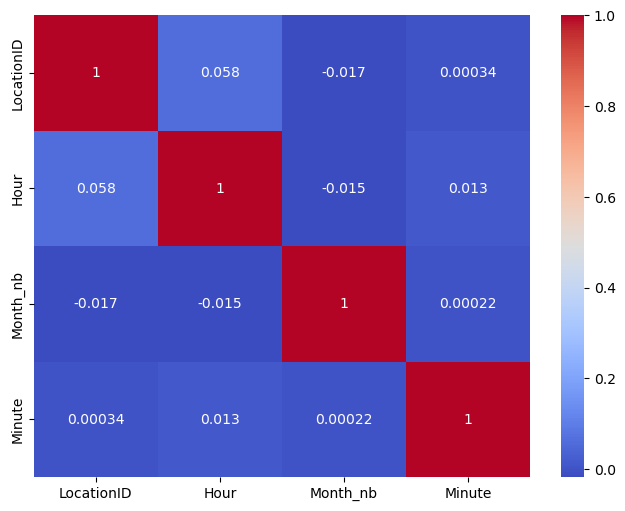

In [541]:
numeric_cols = ["LocationID",'Hour','Month_nb','Minute']
corr_matrix = uber_2015_sampled[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

With a quick exploration, it seams that we don't have correlation between time and location (but we need to combine latitude and longitude for a better explanation)

**3.5. Spatial analysis**

We can analyze the global distribution of the rides to see if some zones are more demanded than others.

In [542]:
# Top hotspots
hotspots = uber_2015.groupby(['Zone', 'Latitude', 'Longitude']).size().reset_index(name='Pickups')
hotspots = hotspots.sort_values('Pickups', ascending=False)

print(f"\nTop 10 hotspots:")
for idx, row in hotspots.head(10).iterrows():
    print(f"  {row['Zone']}: {row['Pickups']:,} pickups")



Top 10 hotspots:
  Midtown Center: 22,469 pickups
  Union Sq: 20,617 pickups
  TriBeCa/Civic Center: 20,546 pickups
  East Village: 20,024 pickups
  West Village: 15,831 pickups
  Times Sq/Theatre District: 15,559 pickups
  East Chelsea: 14,825 pickups
  Murray Hill: 14,307 pickups
  Midtown North: 14,208 pickups
  Midtown East: 14,020 pickups


In [ ]:
# Create density map
fig = px.scatter_map(
    hotspots,
    lat='Latitude',
    lon='Longitude',
    size='Pickups',
    hover_name='Zone',
    color='Pickups',
    zoom=10,
    center={'lat': 40.7128, 'lon': -74.0060},
    title=f"Uber Hotspots 2015",
    color_continuous_scale='YlOrRd',
    height=700
)

fig.update_layout(mapbox_style='open-street-map')
fig.show()

Here the information is not as precise as the dataset of 2014 because we have the location of the taxi zone and not the exact picking-up coordinates. But we can still see that the closest from the city center and the more rides are done.

**3.6. Temporal analysis**

We can now analyze the influence of time on the number of rides with diffent scales :
- the whole period (from April to September 2014),
- Monthly
- Weekly
- Daily

_3.6.1. Analysis on the whole period_

In [ ]:
# Rides per date throughout the whole period
ride_per_date = pd.DataFrame(uber_2015.groupby(["Date"]).size(),columns=["Nb_ride"])
fig = px.line(ride_per_date,width=1000)
fig.show()

It looks like we have a cyclic number of rides per month. Let's dive deeper into the month per month analysis

In [ ]:
# Ratio of rides per month
ride_per_month=pd.DataFrame(uber_2015.groupby(["Month"],sort=False).size(),columns=["Nb_ride"])
ride_per_month["Ratio/Month (%)"]=ride_per_month["Nb_ride"].apply(lambda x: round(100*x/sum(ride_per_month["Nb_ride"]),2))
ride_per_month.sort_values(["Ratio/Month (%)"], ascending=False)

We can observe that June and May have more rides thant January and February. We can suggest that warmer temperatures make people want to go out more often.

_3.6.2. Analysis on a montly period_

In [ ]:
# We create a dictionary with :
# - each month as a key
# - each corresponding dataframe as values (uber_2015 filtered per month)

list_month=list(ride_per_month.index)
uber_month_15_dict={month: uber_2015[uber_2015["Month"]==month].copy() for month in list_month}


In [ ]:
# We plot each graph with the day of week as a background to observe the cyclical number of rides for each month

colors = {
    "Monday": "#CEE8E9",
    "Tuesday": "#7fe2f1",
    "Wednesday": "#6bb9f5",
    "Thursday": "#328fb4",
    "Friday": "#1564A0",
    "Saturday": "#F0D521",
    "Sunday": "#E2AA2F"
}

for month,df_month in uber_month_15_dict.items():
    df_month.copy()
    daily_count=df_month.groupby(["Date", "Weekday"]).size().reset_index(name="Nb_rides")
    fig=px.line(daily_count, x="Date", y="Nb_rides", title=f"Number of rides in {month} 2015")

    # We add in the background the day names
    for _, row in daily_count.iterrows():
        row["Date"]=pd.to_datetime(row["Date"]).date()
        day=row["Date"]
        day_name=row["Weekday"]
        fig.add_vrect(
            x0=day, # x0 : midnight of the day
            x1=day + pd.Timedelta(days=1), # x1 : midnight of the following day
            fillcolor=colors.get(day_name,"#ffffff"),
            opacity=0.25,
            layer="below",
            line_width=0, # to avoid a line around the rectangle
            )
    for day_name, color in colors.items(): # we add an invisible trace in order to have the legend
        fig.add_scatter(
            x=[None], y=[None],
            mode="markers",
            marker=dict(size=10, color=color),
            name=day_name,
            showlegend=True
            )
    fig.update_layout(
        xaxis_title="Date",
        yaxis_title="Number of rides",
        plot_bgcolor="white"
    )

    fig.show()


We can clearly observe that every month there is a cyclic demand for Uber rides with a growing demand during the working days and a pick on Saturdays then a drop on Sundays and Mondays.

_3.6.3. Analysis on a weekly period_

In [ ]:
# Ratio of rides per weekday
ride_per_weekday=pd.DataFrame(uber_2015.groupby(["Weekday"],sort=False).size(),columns=["Nb_ride"])
ride_per_weekday["Ratio/Week (%)"]=ride_per_weekday["Nb_ride"].apply(lambda x: round(100*x/sum(ride_per_weekday["Nb_ride"]),2))
ride_per_weekday.sort_values(["Ratio/Week (%)"], ascending=False)

In [ ]:
order_days=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"] # we create a list of days in the good order so Plotly doesn't give us a result in an alphabetical order
fig_ride_per_weekday=px.bar(ride_per_weekday, y="Nb_ride", width=500, category_orders={"Weekday":order_days})
fig_ride_per_weekday.show()

This confirm what we saw above : There is a pick of demand on Friday and Saturday and a decrease on Sunday and Monday.

_3.6.4. Analysis on a daily period_

We have observed seasonal variation, then variations throughout the weeks with some days with a higher demand than other days, let's now check the evolution of the demand per day, according to the different weekdays.

In [ ]:
# Ratio of rides per hour and per day of week

ride_per_hour_day=uber_2015.groupby(["Weekday","Hour"],as_index=False).size().rename(columns={"size" : "Nb_ride"})
ride_per_hour_day["Ratio/Hour (%)"]=ride_per_hour_day["Nb_ride"].apply(lambda x: round(100*x/sum(ride_per_hour_day["Nb_ride"]),2))
ride_per_hour_day.sort_values(["Ratio/Hour (%)"], ascending=False)

In [ ]:
# Top 15 days and hours with more rides :
top_15_hours=ride_per_hour_day.sort_values(["Ratio/Hour (%)"], ascending=False).head(15)
top_15_hours

The schedules with more rides are mainly happening from 7pm to 11pm on Fridays and Saturdays

In [ ]:
# Last 15 days and hours with more rides :
last_15_hours=ride_per_hour_day.sort_values(["Ratio/Hour (%)"], ascending=False).tail(15)
last_15_hours

The schedules with less rides are mainly from 2 am to 4 am during the working days.

In [ ]:
# What are times where more rides are done according to the day of the week?
fig=px.bar(ride_per_hour_day,x="Weekday",y="Nb_ride",color="Hour",category_orders={"Weekday":order_days},color_continuous_scale="Aggrnyl")
fig.show()


We can observe :
- (once again) an increase in the number of rides during the working days with a pick Saturdays and a drop on Sundays and Mondays.
- A distribution of the number of rides quite similar from Monday to Friday with an increase of night rides (from 0 to 6 am. on Saturdays and Sundays. This correspond to what we could expect (more people going out with a Uber service lately during on weekends)).

In [ ]:
# Ratio of rides per hour and per day of week

ride_per_hour_day=uber_2015.groupby(["Weekday","Hour"],as_index=False).size().rename(columns={"size" : "Nb_ride"})
ride_per_hour_day["Ratio/Hour (%)"]=ride_per_hour_day["Nb_ride"].apply(lambda x: round(100*x/sum(ride_per_hour_day["Nb_ride"]),2))
ride_per_hour_day.sort_values(["Ratio/Hour (%)"], ascending=False)

In [ ]:
fig = px.line(ride_per_hour_day, x='Hour', y='Nb_ride', facet_row='Weekday',width=600,height=1500,category_orders={"Weekday":order_days})
fig.show()

We can observe the same kind of patterns for the working days with a pick around 7 am in the morning and a bigger one around 5 pm this correspond to "normal" working schedule so we can imagine that a lot of people are using Uber to go to the office and even more to come back from the office. On the weekend we don't have this "morning pick" but more rides during the afternoon and the nights on Fridays and Saturdays.  

**3.7. Spatio-temporal analysis**

We know that we have some picks of the demand of rides from 6 to 9 am and from 6 to 10 pm on working days. Let's see that on a map.

In [ ]:
working_day=["Monday","Tuesday","Wednesday","Thursday","Friday"]
weekend=["Saturday","Sunday"]

morning_hours=[6,7,8,9]
evening_hours=[15,16,17,18,19,20,21]

In [ ]:
uber_2015["Hour"] = uber_2015["Hour"].astype(int) # we convert the hours as integer to sort them chronologicaly (and not alphabeticaly in the animation)
uber_2015_wkday=uber_2015[uber_2015["Weekday"].isin(working_day)]
uber_2015_wkday = uber_2015_wkday.sort_values(by='Hour')

In [ ]:
fig_workingday_pick = px.density_map(
    uber_2015_wkday,
    lat='Latitude',
    lon='Longitude',
    radius=5,  # controls the "spread" of each point
    center=dict(lat=40.75, lon=-73.97),  # NYC center
    zoom=10,
    map_style='carto-positron',
    color_continuous_scale='YlOrRd',
    animation_frame="Hour",
    height=900,
    title="Density map of the Uber rides in New York during working days in 2015"
)


fig_workingday_pick.show()

In [ ]:
uber_2015_weekend=uber_2015_sampled[uber_2015_sampled["Weekday"].isin(weekend)]
uber_2015_weekend= uber_2015_weekend.sort_values(by='Hour')

fig_weekend_pick = px.density_map(
    uber_2015_weekend,
    lat='Latitude',
    lon='Longitude',
    radius=5,  # controls the "spread" of each point
    center=dict(lat=40.75, lon=-73.97),  # NYC center
    zoom=10,
    map_style='carto-positron',
    color_continuous_scale='YlOrRd',
    animation_frame="Hour",
    title="Density map of the Uber rides in New York during weekends in 2015"
)


fig_weekend_pick.show()

**3.8. Bases analysis**

Online researches teach us that :

_"Base refers to the dispatch base (base station) with which each Uber vehicle is affiliated.
Each base is an operational or commercial license authorized by the NYC Taxi & Limousine Commission (TLC).
In practice, a “base” is a local company registered with the TLC to operate for-hire vehicles, and Uber uses several licensed bases to operate in New York City"_

Let's check what are the number of rides per base and the area covered by each base.

In [ ]:
ride_per_base=pd.DataFrame(uber_2015.groupby(["Dispatching_base_num"]).size(),columns=["Nb_ride"])
fig_ride_per_base=px.bar(ride_per_base, width=600, height=400)
fig_ride_per_base.show()

We can see a huge difference in the number of rides per bases. Some are more active than others. Maybe they are older or have  more taxi drivers. Let's check the area covered by each base.

In [ ]:
map_ride_per_base=px.scatter_map(uber_2015,lat="Latitude",lon="Longitude",color="Dispatching_base_num")
map_ride_per_base.show()

It seems that there is no clear seperation of the area covered by each base.

### **5. Comparing 2014 and 2015**

The two datasets cover different periods and use different data formats, which makes a direct merge impractical. Instead, we compare them along three axes: data structure, temporal patterns, and spatial patterns.

**5.1. Data structure**

| | 2014 | 2015 |
|---|---|---|
| Period | April – September | January – June |
| Raw dataset size | ~960,000 rides | ~10,300,000 rides |
| Sampled dataset | ~48,000 rides (5%) | ~493,000 rides (5%) |
| Location format | Raw GPS (Lat/Lon) | Taxi zone LocationID → geocoded |
| Base information | Single `Base` column | `Dispatching_base_num` + `Affiliated_base_num` |
| Duplicates | 0.09% | 0.40% |
| Missing values | None | 1.12% (`Affiliated_base_num`) |

The tenfold increase in volume between 2014 and 2015 reflects Uber's rapid growth in New York City during that period.

In [2]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

uber_2014 = pd.read_csv("../DATA/DATA_created/uber_raw_sample_14.csv")
uber_2015 = pd.read_csv("../DATA/DATA_created/uber_2015_final_for_modelling.csv")

# Monthly ratio per year
ride_per_month_14 = uber_2014.groupby("Month").size().reset_index(name="Nb_ride")
ride_per_month_14["Ratio (%)"] = 100 * ride_per_month_14["Nb_ride"] / ride_per_month_14["Nb_ride"].sum()
ride_per_month_14["Year"] = "2014"

ride_per_month_15 = uber_2015.groupby("Month").size().reset_index(name="Nb_ride")
ride_per_month_15["Ratio (%)"] = 100 * ride_per_month_15["Nb_ride"] / ride_per_month_15["Nb_ride"].sum()
ride_per_month_15["Year"] = "2015"

combined_months = pd.concat([ride_per_month_14, ride_per_month_15])

order_months = ["January","February","March","April","May","June","July","August","September"]
fig = px.bar(
    combined_months,
    x="Month", y="Ratio (%)", color="Year",
    barmode="group",
    category_orders={"Month": order_months},
    title="Monthly ride distribution — 2014 vs 2015 (% of each year's total)",
    width=800
)
fig.show()

**5.2. Seasonal patterns**

The two years cover different seasons, so the comparison is partial, but April–June are common to both.

- In **2014**, demand grows steadily from April (+16–17%) through August (+18%) and peaks in September (+20%).  
- In **2015**, the winter months (January–February) record the lowest demand, while May and June show the highest (+18–19%), confirming that warmer weather drives ridership.

On the common months (April–June), the relative distribution is similar in both years, suggesting stable underlying demand patterns across seasons.

In [3]:
order_days = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

ride_per_day_14 = uber_2014.groupby("Weekday").size().reset_index(name="Nb_ride")
ride_per_day_14["Ratio (%)"] = 100 * ride_per_day_14["Nb_ride"] / ride_per_day_14["Nb_ride"].sum()
ride_per_day_14["Year"] = "2014"

ride_per_day_15 = uber_2015.groupby("Weekday").size().reset_index(name="Nb_ride")
ride_per_day_15["Ratio (%)"] = 100 * ride_per_day_15["Nb_ride"] / ride_per_day_15["Nb_ride"].sum()
ride_per_day_15["Year"] = "2015"

combined_days = pd.concat([ride_per_day_14, ride_per_day_15])

fig = px.bar(
    combined_days,
    x="Weekday", y="Ratio (%)", color="Year",
    barmode="group",
    category_orders={"Weekday": order_days},
    title="Weekly ride distribution — 2014 vs 2015 (% of each year's total)",
    width=800
)
fig.show()

We can see that in 2015 the Uber rides are more used during the weekend then during the week compared to 2014.

In [4]:
ride_per_hour_14 = uber_2014.groupby("Hour").size().reset_index(name="Nb_ride")
ride_per_hour_14["Ratio (%)"] = 100 * ride_per_hour_14["Nb_ride"] / ride_per_hour_14["Nb_ride"].sum()
ride_per_hour_14["Year"] = "2014"

ride_per_hour_15 = uber_2015.groupby("Hour").size().reset_index(name="Nb_ride")
ride_per_hour_15["Ratio (%)"] = 100 * ride_per_hour_15["Nb_ride"] / ride_per_hour_15["Nb_ride"].sum()
ride_per_hour_15["Year"] = "2015"

combined_hours = pd.concat([ride_per_hour_14, ride_per_hour_15])

fig = px.line(
    combined_hours,
    x="Hour", y="Ratio (%)", color="Year",
    title="Hourly ride distribution — 2014 vs 2015",
    width=800
)
fig.show()

Despite the format differences and partial period overlap, the two datasets tell a coherent story: demand is growing rapidly, temporal patterns are stable but shifting slightly toward weekend and social use.